In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/content/credit_card_fraud_10k.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


is_fraud
0    9849
1     151
Name: count, dtype: int64


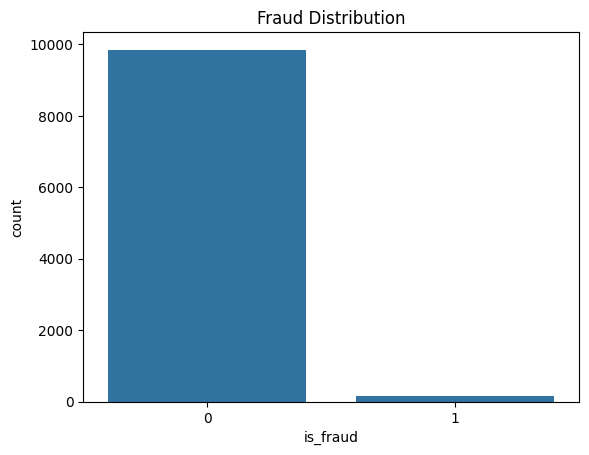

In [ ]:
import seaborn as sns
print(df["is_fraud"].value_counts())
sns.countplot(x="is_fraud",data=df)
plt.title("Fraud Distribution")
plt.show()

In [ ]:
X=df.drop("is_fraud",axis=1)
y=df["is_fraud"]

In [ ]:
X=pd.get_dummies(X,columns=["merchant_category"],
                 drop_first=True
                 )

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(
    X_train_scaled,
    y_train
)
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [ ]:
svm=SVC(
    kernel="rbf", #Radial Basis Function
    probability=True,
    class_weight="balanced",
    random_state=42
)
svm.fit(X_train_smote,y_train_smote)

svm_pred=svm.predict(X_test_scaled)
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.40      0.80      0.53        30

    accuracy                           0.98      2000
   macro avg       0.70      0.89      0.76      2000
weighted avg       0.99      0.98      0.98      2000



In [ ]:
xgb=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train_smote,y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred=xgb.predict(X_test_scaled)
print(classification_report(y_test,xgb_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.81      1.00      0.90        30

    accuracy                           1.00      2000
   macro avg       0.91      1.00      0.95      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
xgb_prob=xgb.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(
    y_test,
    xgb_prob
)
print("ROC AUC =", auc)


ROC AUC = 0.9994923857868021


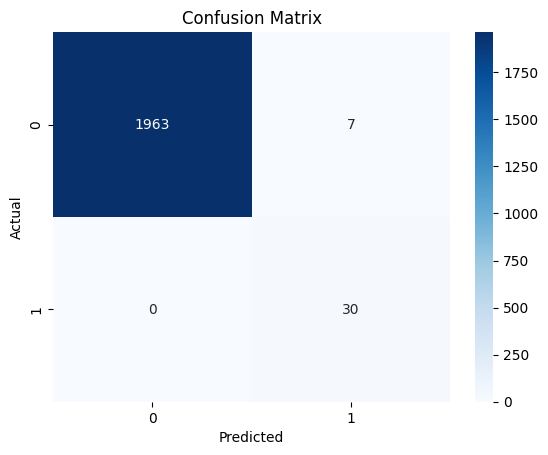

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                      Feature  Importance
2            transaction_hour    0.243844
4           location_mismatch    0.195183
3         foreign_transaction    0.179270
5          device_trust_score    0.172353
6           velocity_last_24h    0.095820
1                      amount    0.028358
11   merchant_category_Travel    0.021430
9      merchant_category_Food    0.014889
0              transaction_id    0.014288
10  merchant_category_Grocery    0.013224


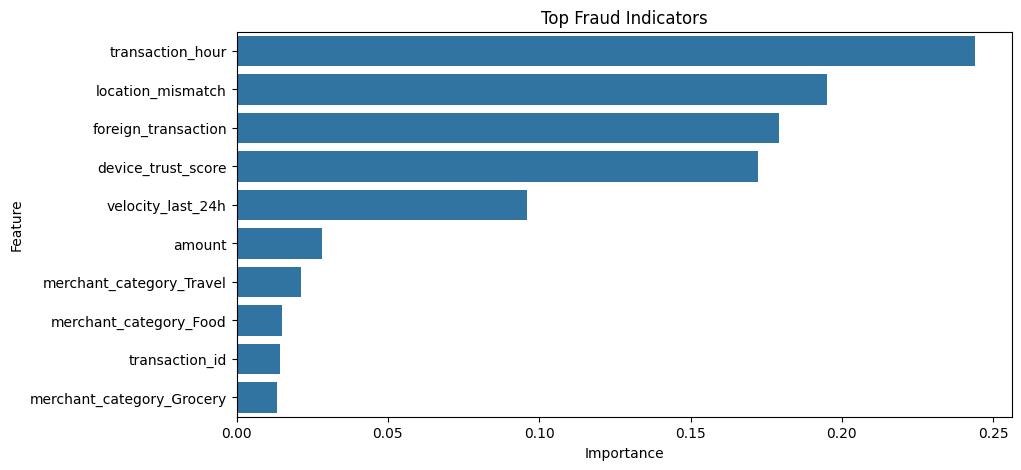

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Fraud Indicators")
plt.show()

In [ ]:
for threshold in [0.1,0.2,0.3,0.4,0.5,0.6]:

    pred = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        pred
    )

    recall = recall_score(
        y_test,
        pred
    )

    print(
        f"Threshold={threshold:.1f} "
        f"Precision={precision:.3f} "
        f"Recall={recall:.3f}"
    )

Threshold=0.1 Precision=0.441 Recall=1.000
Threshold=0.2 Precision=0.545 Recall=1.000
Threshold=0.3 Precision=0.682 Recall=1.000
Threshold=0.4 Precision=0.750 Recall=1.000
Threshold=0.5 Precision=0.811 Recall=1.000
Threshold=0.6 Precision=0.857 Recall=1.000
